# Urgency Classification
This notebook looks at automated urgency classification that is targeted to be performed in small healthcare facilities (e.g., General Practitioners). This technique looks at patient data and assesses the need to render urgent care to them. These are the steps taken:
1. **Setting up environment:** Setting up the environment (Imports, configurations, Path existence).
2. **Load Data:** Load the dataset used for training the model (Loading of data into Pandas DataFrame).
3. **Analyse Data:** Understand the data and characteristics of the dataset.
4. **Seperate attributes from target:** Seperate dataframes `X` and `y`.
5. **Vanilla Logistic Regression Model:** Implement vanilla logistic regression model with evaluation.
6. **Enhancements:** Applying Recursive Feature Elimination and Grid Search to enhance the model.

## Step 1: Setting up environment
This steps sets up the environment for the rest of the sections through the following sub-steps.
- **Imports:** Resolves imports
- **Configurations:** Set environment variables and configurations (e.g., data_filename)
- **Path Resolution:** Safely ensures that the paths used in the notebook are all created.

In [1]:
import pickle
from typing import Literal

import pandas as pd
from pandas import DataFrame, Series
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    r2_score,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import MinMaxScaler

In [2]:
# Set the filename of the dataset to read from for modelling
data_filename: str = "patient_priority_modified.csv"

# Configuration to set fixed names for models
MODEL_NAMES = Literal["vanilla", "rfe", "grid"]

# Include option to save model
save_model: bool = True
models_to_save: list[MODEL_NAMES] = ["vanilla", "rfe", "grid"]

In [3]:
import os

CWD = os.getcwd()
ROOT = os.path.abspath(os.path.join(CWD, ".."))


# Create Function to create a directory
def create_folder(relative_path: str):
    """
    Helper function to create a folder if it does not exists and return file path

    Args:
        relative_path (str): Relative Path with respect to root

    Returns:
        str: String containing absolute file path
    """
    path = os.path.join(ROOT, relative_path)
    try:
        os.makedirs(path, exist_ok=True)
        print(f"Ensured directory '{path}' exists")
    except OSError as exc:
        print(f"Exception faced when creating folder '{path}': {exc}")
    return os.path.abspath(path)


DATA_DIR = create_folder(relative_path="data")
MODEL_DIR = create_folder(relative_path="models")

Ensured directory 'c:\DBTT\DBTT_G5T1\data' exists
Ensured directory 'c:\DBTT\DBTT_G5T1\models' exists


## Step 2: Load Data
Based on the data filename indicated in the configurations in step 1, this step looks at reading the data file from the data directory and loading it as a pandas DataFrame `pd.DataFrame`.

In [4]:
import os


def extract_dataframe_from_file(file_name: str, dir_path: str) -> dict[str, DataFrame]:
    """
    Finds the Data directory for file with specified filename and retrieve as a DataFrame

    Args:
        filename (str): Name that the filename should contain.
        dir_path (str): Path of directory containing filename

    Raises:
        ValueError: If filename is invalid, or filetype is wrong
        FileNotFoundError: if file is not found in the directory

    Returns:
        dict[str, Dataframe]: Dictionary mapping sheet_name to DataFrame. For CSV, it maps the filename to the DataFrame.
    """
    if not file_name.lower().endswith((".csv", ".xlsx", ".xls")):
        raise ValueError(f"Invalid filename received: {file_name}")

    # Build full absolute path
    file_path = os.path.abspath(os.path.join(dir_path, file_name))

    if not os.path.exists(file_path):
        raise FileNotFoundError(f"File not found in '{dir_path}': {file_name}")

    # Instantiate dictionary to manage mapping
    dfs: dict[str, DataFrame] = {}

    # Load file based on extension
    if file_name.lower().endswith(".csv"):
        dfs[file_name] = pd.read_csv(file_path, index_col=False)

    else:
        # Open the Excel file
        xls = pd.ExcelFile(file_path)

        # Loop through each sheet
        for sheet_name in xls.sheet_names:
            dfs[sheet_name] = pd.read_excel(xls, sheet_name=sheet_name, index_col=False)

    # Return dictionary
    return dfs


# Extract DataFrames and print out Dataframes names
dfs: dict[str, DataFrame] = extract_dataframe_from_file(
    file_name=data_filename, dir_path=DATA_DIR
)
print(f"List of DataFrame names: {list(dfs.keys())}")

List of DataFrame names: ['patient_priority_modified.csv']


In [5]:
# Extract DataFrame for CSV
df = dfs.get(data_filename)

## Step 3: Analyse Data
This step analyses the data to better understand the characteristics of the modified dataset.

- **Numerical:** age, chest_pain_type, blood_pressure, max_heart_rate, bmi, diabetes_pedigree
- **Binary:** gender, exercise_angina, hypertension, heart_diease, y
- **Categorical:** smoking_status, Residence_type, smoking_status

In [6]:
# View DataFrame
df.head(5)

,age,chest pain type,blood pressure,max heart rate,exercise angina,bmi,hypertension,heart_disease,smoking_status,y
0,40.0,2.0,140.0,172.0,0.0,19.0,0.0,0.0,never smoked,0
1,49.0,3.0,160.0,156.0,0.0,18.0,0.0,0.0,never smoked,1
2,37.0,2.0,130.0,156.0,0.0,23.0,0.0,0.0,never smoked,0
3,48.0,4.0,138.0,156.0,1.0,18.0,0.0,0.0,never smoked,1
4,54.0,3.0,150.0,156.0,0.0,21.0,0.0,0.0,never smoked,0


In [7]:
# Summary Statistics
df.describe(include="all")

,age,chest pain type,blood pressure,max heart rate,exercise angina,bmi,hypertension,heart_disease,smoking_status,y
count,6552.000000,6552.000000,6552.000000,6552.000000,6552.000000,6552.000000,6552.000000,6552.000000,6552,6552.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,never smoked,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3543,NaN
mean,58.233822,0.560592,110.490842,163.418956,0.065324,27.558318,0.075092,0.041667,NaN,0.072497
std,11.809133,1.285283,21.634696,15.451970,0.247115,7.403318,0.263559,0.199842,NaN,0.259329
min,28.000000,0.000000,60.000000,138.000000,0.000000,10.300000,0.000000,0.000000,NaN,0.000000
25%,49.000000,0.000000,93.000000,150.000000,0.000000,22.000000,0.000000,0.000000,NaN,0.000000
50%,57.000000,0.000000,113.000000,163.000000,0.000000,26.700000,0.000000,0.000000,NaN,0.000000
75%,66.000000,0.000000,128.000000,177.000000,0.000000,31.400000,0.000000,0.000000,NaN,0.000000


## Step 4: Separate the attributes and target

Since the data is read as a whole into the dataframe `df`, there is a need to **separate** `df` into 2 parts:
- **Input variables** or attributes used for prediction
- **Target value** which is actually the label of the input values, indicating the y (urgency of patient).

`X = df.drop('y', axis=1)` is to create `X` client information and removing the last column (`'y'`). In deed, it doesn't make sense to include 'y' in the data to train the model since it is the target we want to learn and predict.

`y = df['y']` is creating a Series that contains only the target variable, with 0 indicating non-urgent cases, 1 indicating urgent cases.

In [8]:
# Seperate the input (X) and output (y) dataframes
X: DataFrame = df.drop("y", axis=1)
y: Series = df["y"]

print(X.shape, y.shape)

(6552, 9) (6552,)


In [9]:
# View distribution of classes
print(y.value_counts())

y
0    6077
1     475
Name: count, dtype: int64


In [10]:
# View 5 entries of X
X.head(5)

,age,chest pain type,blood pressure,max heart rate,exercise angina,bmi,hypertension,heart_disease,smoking_status
0,40.0,2.0,140.0,172.0,0.0,19.0,0.0,0.0,never smoked
1,49.0,3.0,160.0,156.0,0.0,18.0,0.0,0.0,never smoked
2,37.0,2.0,130.0,156.0,0.0,23.0,0.0,0.0,never smoked
3,48.0,4.0,138.0,156.0,1.0,18.0,0.0,0.0,never smoked
4,54.0,3.0,150.0,156.0,0.0,21.0,0.0,0.0,never smoked


In [11]:
# View 5 entries of X
y.head(5)

0    0
1    1
2    0
3    1
4    0
Name: y, dtype: int64

## Step 5: Preprocess Data
- Columns containing **numeric variables**:
Since the range of input values are of different scales (from `df.describe()`), there is a need to **normalize** the values between `0-1` so that the range of values won't influence the model. It is important to do the **same scaling** on both input values of training data (`X_train`) and testing data (`X_test`) to ensure meaningful evaluation.

- Columns which contain **binary variables**:
It is necessary to ensure the datatype is either boolean or int (0/1) to be consistent with the dummy encoding done on categorical variables.

- Columns which contain **categorical variables**:
It is necessary to convert them using **dummy encoding**. Dummy encoding creates <i>k</i>-1 binary (0 or 1) columns for a categorical variable with <i>k</i> unique categories. We use <i>k</i>-1 variables to avoid redundancy in the model, since including all <i>k</i> would make one variable completely determined by the rest. This approach also has the benefit of not weighting a value improperly.

In [12]:
# Set numeric_cols and categorical_cols
numeric_cols = ["age", "blood pressure", "max heart rate", "bmi"]
binary_cols = ["exercise angina", "hypertension", "heart_disease"]
categorical_cols = ["chest pain type", "smoking_status"]
all_cols = numeric_cols + binary_cols + categorical_cols

### 5a: Handle Missing Data

In [13]:
# View frequency of missing data
X.isna().sum()

age                0
chest pain type    0
blood pressure     0
max heart rate     0
exercise angina    0
bmi                0
hypertension       0
heart_disease      0
smoking_status     0
dtype: int64

In [14]:
def handle_missing_data(
    X: DataFrame,
    y: Series,
    cols: list[str],
    choice: Literal["drop", "replace"] = "replace",
) -> tuple[DataFrame, Series]:
    """
    Function to handle missing data based on the choice decide.

    Args:
        X (DataFrame): DataFrame to check for missing data in specified col.
        y (Series): Series containing the target value
        col (str): Column to check for missing data
        choice (str): Selection of how to handle missing data. Defaults to "replace"

    Returns:
        DataFrame: Modified X without missing data
        Series: Modified y without rows with missing col data
    """

    if choice == "drop":
        X = X.dropna(subset=cols)

        # Keep y aligned using the index
        y = y.loc[X.index]

    elif choice == "replace":
        # Fill nan in all columns with "Unknown"
        for col in cols:
            X[col] = X[col].fillna("Unknown")

    # Return X and y
    return X, y

In [15]:
# We choose the drop any np.nan data if any
X, y = handle_missing_data(X=X, y=y, cols=all_cols, choice="drop")
print(X.shape, y.shape)
X.isna().sum()

(6552, 9) (6552,)


age                0
chest pain type    0
blood pressure     0
max heart rate     0
exercise angina    0
bmi                0
hypertension       0
heart_disease      0
smoking_status     0
dtype: int64

### Step 5b: Perform Train-Test split on data
Perform an 80-20 train-test split with `random_state` to allow **reproducibility** and `stratify` to ensure the **distribution of labels is consistent** in both train and test sets.

In [16]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=10, stratify=y
)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(5241, 9) (1311, 9) (5241,) (1311,)


### Step 5c: Preprocess data separately on Train and Test datasets
Data are **preprocessed separately** to ensure that there is strictly **no data leakage**. For numerical columns, individual scalars are **fit-transform** only on the training set and respective column scalars **transform** the test column data.

In [17]:
def preprocess_data(
    X: DataFrame,
    numeric_cols: list[str],
    binary_cols: list[str],
    categorical_cols: list[str],
    train: bool = True,
    scalers: dict[str, MinMaxScaler] = {},
) -> tuple[DataFrame, dict[str, MinMaxScaler]]:
    """
    Function to preprocess data from X. This step should be performed after train-test split to not have data leakage.

    Args:
        X (DataFrame): DataFrame to be preprocessed.
        numerical_cols (list[str]): List of cols to be treated as numeric and scaled.
        binary_cols (list[str]): List of cols to be treated as binary data and converted to int.
        categorical_cols (list[str]): List of cols to be treated as categorical data and dummy encoded.
        train (bool): Boolean to represent if numeric scalers should be
    """

    # Store all mapping of numeric cols to respective fitted scaler
    new_scalers = {}

    # Numeric Columns are normalised using MinMaxScaler to constrain values between 0 and 1
    for col in numeric_cols:

        # For training dataset, we create a new scaler and store it in the scalers dict
        if train:
            # Initialise new scaler
            scaler = MinMaxScaler(feature_range=(0, 1))
            # Apply fit_transform() of scaler
            X[col] = scaler.fit_transform(X[[col]])
            # Add fitted scaler to new_scalers dictionary
            new_scalers[col] = scaler

        # For val/test datasets, we use the existing scaler from scalers dict provided
        else:
            X[col] = scalers.get(col).transform(X[[col]])

    print("Successfully processed numeric column(s)")

    # Binary columns are converted to int
    for col in binary_cols:
        X[col] = X[col].astype(int)

    print("Successfully processed binary column(s)")

    # Categorical columns are encoded through converting the column into dummy encoding using get_dummies() (from pandas).
    # Removing drop_first will change it to one-hot encoding
    X = pd.get_dummies(X, columns=categorical_cols, drop_first=True, dtype=int)

    print("Successfully processed categorical column(s)")

    return X, new_scalers

In [18]:
# Preprocess X_train
X_train, scalers = preprocess_data(X_train, numeric_cols, binary_cols, categorical_cols)
X_train.head(5)

Successfully processed numeric column(s)
Successfully processed binary column(s)
Successfully processed categorical column(s)


,age,blood pressure,max heart rate,exercise angina,bmi,hypertension,heart_disease,chest pain type_1.0,chest pain type_2.0,chest pain type_3.0,chest pain type_4.0,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
3826,0.222222,0.533333,0.625000,0,0.265487,0,0,0,0,0,0,1,0,0
4281,0.759259,0.580952,0.500000,0,0.394690,1,0,0,0,0,0,1,0,0
2731,0.537037,0.428571,0.125000,0,0.449558,0,0,0,0,0,0,1,0,0
5000,0.796296,0.523810,0.437500,0,0.194690,0,0,0,0,0,0,0,1,0
4884,0.388889,0.628571,0.640625,0,0.178761,0,0,0,0,0,0,0,0,0


In [19]:
# Preprocess X_test using scalers obtained from fit stage
X_test, _ = preprocess_data(
    X_test, numeric_cols, binary_cols, categorical_cols, train=False, scalers=scalers
)
X_test.head(5)

Successfully processed numeric column(s)
Successfully processed binary column(s)
Successfully processed categorical column(s)


,age,blood pressure,max heart rate,exercise angina,bmi,hypertension,heart_disease,chest pain type_1.0,chest pain type_2.0,chest pain type_3.0,chest pain type_4.0,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
4599,0.888889,0.476190,0.765625,0,0.608850,0,0,0,0,0,0,1,0,0
4890,0.592593,0.400000,0.093750,0,0.056637,0,0,0,0,0,0,0,0,0
1416,0.388889,0.266667,0.250000,0,0.299115,0,0,0,0,0,0,0,1,0
2018,0.870370,0.285714,0.265625,0,0.389381,0,0,0,0,0,0,0,0,1
4889,0.592593,0.485714,0.328125,0,0.281416,0,0,0,0,0,0,0,1,0


In [20]:
# Save scalar dictionary as a pickle file
if save_model:
    save_path = os.path.join(MODEL_DIR, "patient_scalers_dict.pkl")
    with open(save_path, "wb") as f:
        pickle.dump(scalers, f)

## Step 6: Vanilla Logistics Regression Model
Implementing a logistics regression model and fitting it only on the train set. The model will be evaluated on the test dataset on accuracy, R2 score and confusion matrix (e.g., Precision, Recall, F1-Score).

In [21]:
# Create a logistic regression classifier and fit on train data
logreg = LogisticRegression(solver="liblinear", random_state=7)
logreg.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",7
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multic

----------------------------
Testing accuracy 0.9672006102212052
Testing R2 score 0.5120065789473686
----------------------------
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1216
           1       0.98      0.56      0.71        95

    accuracy                           0.97      1311
   macro avg       0.97      0.78      0.85      1311
weighted avg       0.97      0.97      0.96      1311



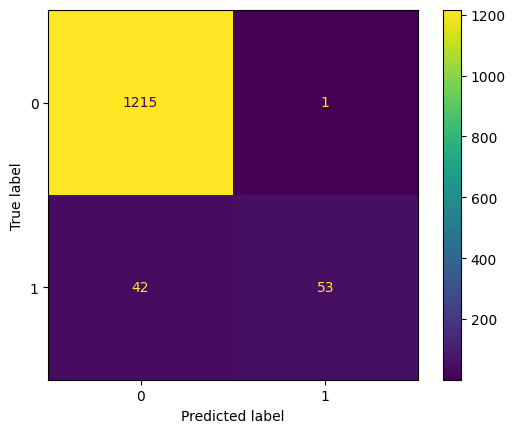

In [22]:
# Apply the model on the test data to get a prediction
y_pred = logreg.predict(X_test)

# Get accuracy of the model
print("----------------------------")
print("Testing accuracy %s" % accuracy_score(y_test, y_pred))
print(f"Testing R2 score {r2_score(y_test, y_pred)}")
print("----------------------------")

# Compute confusion matrix
labels = [0, 1]
cm = confusion_matrix(y_test, y_pred, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot()

# Look at the value for both 1 and 0 class, the model can predict 0 better than 1
print(classification_report(y_test, y_pred))

In [23]:
# Save model if required
if save_model and "vanilla" in models_to_save:
    save_path = os.path.join(MODEL_DIR, "patient_vanilla.pkl")
    with open(save_path, "wb") as f:
        pickle.dump(logreg, f)

## Step 7: Enhancements
Possible enhancements to the vanilla Logistic Regression model would be Recursive Feature Elimination (RFE) and Grid Search. Each enhancement will be evaluated on the similar manner as the Vanilla Logistics Regression Model.

### Step 7a: Recursive Feature Elimination
Works by recursively removing attributes and building a model on those attributes that remain.

In [24]:
# Set number of features to select
n_features_to_select = 5

# Defining Recursive Feature Elimination on Logistic Regression model and n selected features
rfe = RFE(logreg, n_features_to_select=n_features_to_select)

# Fit the RFE model on Train Data
rfe.fit(X_train, y_train)

# Fit-Transform on Train data and Transform test data
X_train_selected = rfe.fit_transform(X_train, y_train)
X_test_selected = rfe.transform(X_test)

# Provide details of RFE
print("Num Features: %d" % rfe.n_features_)
print("Selected Features: %s" % rfe.support_)
print("Feature Ranking: %s" % rfe.ranking_)

# Get the top-n feature_names
selected = rfe.support_
feature_names = X_train.columns

# Obtain mapping to feature names
top_features = feature_names[selected]
print(f"Top {n_features_to_select} Features: {list(top_features)}")

Num Features: 5
Selected Features: [ True  True False False  True False False False  True False False False
 False  True]
Feature Ranking: [ 1  1  6  9  1  5  4  7  1  2  3  8 10  1]
Top 5 Features: ['age', 'blood pressure', 'bmi', 'chest pain type_2.0', 'smoking_status_smokes']


In [25]:
# Train a final model and fit on selected columns of X_train_selected
rfe_logreg = LogisticRegression(solver="liblinear", random_state=42)
rfe_logreg.fit(X_train_selected, y_train)

# Use to predict 'y' for the X_test_selected
rfe_logreg

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

----------------------------
Testing accuracy 0.9595728451563692
Testing R2 score 0.3985197368421054
----------------------------
              precision    recall  f1-score   support

           0       0.96      1.00      0.98      1216
           1       0.98      0.45      0.62        95

    accuracy                           0.96      1311
   macro avg       0.97      0.73      0.80      1311
weighted avg       0.96      0.96      0.95      1311



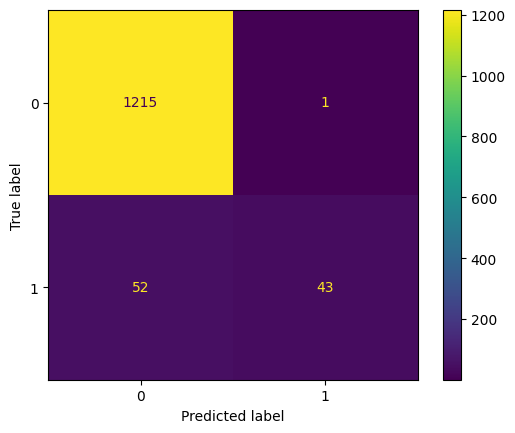

In [26]:
# Apply the model on the test data to get a prediction
y_pred = rfe_logreg.predict(X_test_selected)

# Get accuracy of the model
print("----------------------------")
print("Testing accuracy %s" % accuracy_score(y_test, y_pred))
print(f"Testing R2 score {r2_score(y_test, y_pred)}")
print("----------------------------")

# Compute confusion matrix
labels = [0, 1]
cm = confusion_matrix(y_test, y_pred, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot()

# Look at the value for both 1 and 0 class, the model can predict 0 better than 1
print(classification_report(y_test, y_pred))

In [27]:
# Save model if required
if save_model and "rfe" in models_to_save:
    save_path = os.path.join(MODEL_DIR, "patient_rfe.pkl")
    with open(save_path, "wb") as f:
        pickle.dump(rfe_logreg, f)

### Step 7b: Grid Search
Grid Search finds the best parameters for the given logistic regression model. Since the model prioritises recall, we set `scoring="recall"` to find the best parameters to give the highest recall value for the train set.

In [28]:
# Create a grid search for parameter for logistic regression
param_grid = {"C": [0.01, 0.1, 1, 10, 20]}
grid = GridSearchCV(
    LogisticRegression(solver="liblinear"), param_grid, cv=5, scoring="recall"
)

# Fit grid search on Train data
grid.fit(X_train, y_train)
print("Best cross-validation score: {:.2f}".format(grid.best_score_))
print("Best parameters: ", grid.best_params_)
print("Best estimator: ", grid.best_estimator_)

Best cross-validation score: 0.75
Best parameters:  {'C': 20}
Best estimator:  LogisticRegression(C=20, solver='liblinear')


----------------------------
Testing accuracy 0.9710144927536232
Testing R2 score 0.5687500000000001
----------------------------
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      1216
           1       0.85      0.73      0.78        95

    accuracy                           0.97      1311
   macro avg       0.92      0.86      0.88      1311
weighted avg       0.97      0.97      0.97      1311



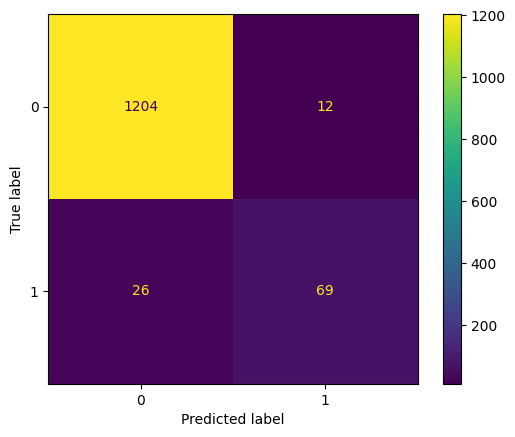

In [29]:
# Make prediction
y_pred = grid.predict(X_test)

# Get accuracy of the model
print("----------------------------")
print("Testing accuracy %s" % accuracy_score(y_test, y_pred))
print(f"Testing R2 score {r2_score(y_test, y_pred)}")
print("----------------------------")

# Compute confusion matrix
labels = [0, 1]
cm = confusion_matrix(y_test, y_pred, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot()

# Look at the value for both 1 and 0 class, the model can predict 0 better than 1
print(classification_report(y_test, y_pred))

In [30]:
# Save model if required
if save_model and "grid" in models_to_save:
    save_path = os.path.join(MODEL_DIR, "patient_grid.pkl")
    with open(save_path, "wb") as f:
        pickle.dump(grid, f)